In [70]:
!pip install ydata-profiling
!pip install scipy==1.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 21.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

In [39]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from scipy.sparse import coo_matrix
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier



In [40]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [55]:
PATH = "/content/customer_dataset_asah_v19_realistic_70_20_10.csv"
df = pd.read_csv(PATH, sep=';')

print("Shape:", df.shape)
display(df.head())

if "label" in df.columns:
    df = df.drop(columns=["label"])

Shape: (10000, 24)


,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,...,duration_days,data_gb,streaming_gb_bonus,gaming_gb_bonus,social_gb_bonus,call_minutes_bonus,sms_bonus,roaming_days_bonus,label,target_offer
0,C00001,Prepaid,Vivo,17.17,0.767,196.51,171,1289235,4,0.251,...,30,15,0,0,25,0,0,0,NaN,Social Offer
1,C00002,Postpaid,Vivo,23.19,0.356,149.02,74,210699,7,0.546,...,30,10,10,0,0,0,0,0,NaN,Streaming Offer
2,C00003,Prepaid,Realme,27.85,0.441,321.96,106,107964,6,0.628,...,30,12,0,0,0,1500,300,0,NaN,Voice Offer
3,C00004,Prepaid,Xiaomi,7.91,0.279,50.58,47,339901,8,0.745,...,30,10,0,0,0,0,0,0,NaN,General Offer
4,C00005,Prepaid,Vivo,10.11,0.974,239.05,76,1986019,2,0.029,...,30,5,10,0,0,0,0,0,NaN,Streaming Offer


In [56]:
print("\nDtypes:")
print(df.dtypes)

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory usage: {mem_mb:.2f} MB")


Dtypes:
customer_id            object
plan_type              object
device_brand           object
avg_data_usage_gb     float64
pct_video_usage       float64
avg_call_duration     float64
sms_freq                int64
monthly_spend           int64
topup_freq              int64
travel_score          float64
complain_count          int64
product_id              int64
product_name           object
price                   int64
duration_days           int64
data_gb                 int64
streaming_gb_bonus      int64
gaming_gb_bonus         int64
social_gb_bonus         int64
call_minutes_bonus      int64
sms_bonus               int64
roaming_days_bonus      int64
target_offer           object
dtype: object

Memory usage: 4.24 MB


## Missing Values

,missing_count,missing_pct


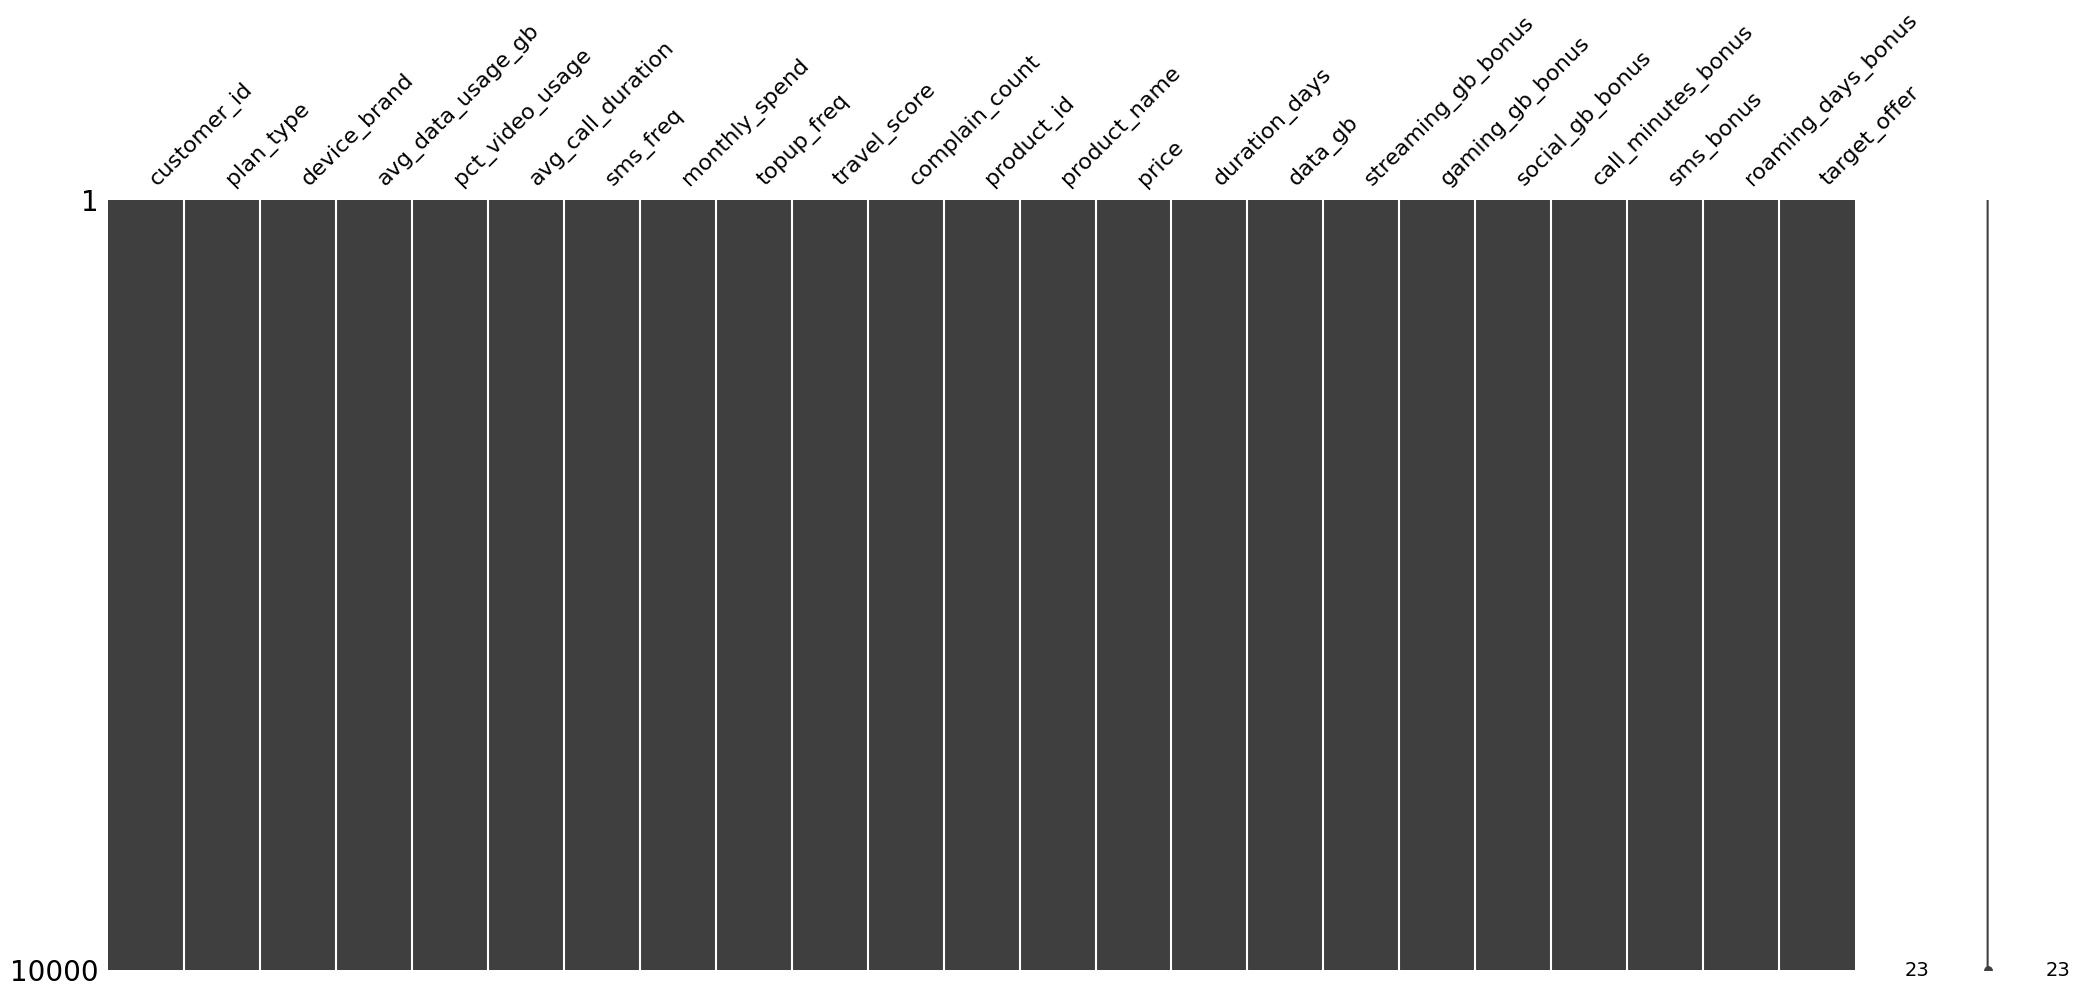

In [57]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
      .query("missing_count > 0")
)
display(missing_df.head(30))
msno.matrix(df)
plt.show()

# Split data jadi kategori dan numerikal

In [58]:
num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = df.select_dtypes(exclude=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print(num_cols)
print("\nCategorical columns:", len(cat_cols))
print(cat_cols)

Numeric columns: 18
['avg_data_usage_gb', 'pct_video_usage', 'avg_call_duration', 'sms_freq', 'monthly_spend', 'topup_freq', 'travel_score', 'complain_count', 'product_id', 'price', 'duration_days', 'data_gb', 'streaming_gb_bonus', 'gaming_gb_bonus', 'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus', 'roaming_days_bonus']

Categorical columns: 5
['customer_id', 'plan_type', 'device_brand', 'product_name', 'target_offer']


Cek data numerik dan ringkasan data

In [59]:
num_desc = df[num_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T.sort_index()
display(num_desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
avg_call_duration,10000.0,2.491661e+02,144.203492,0.0,4.5693,24.72200,124.6775,249.450,3.733775e+02,4.739985e+02,4.954206e+02,499.95
avg_data_usage_gb,10000.0,1.517449e+01,8.670896,0.1,0.4200,1.61950,7.6400,15.255,2.269250e+01,2.861050e+01,2.974010e+01,30.00
call_minutes_bonus,10000.0,2.532400e+02,490.277003,0.0,0.0000,0.00000,0.0000,0.000,5.000000e+02,1.500000e+03,1.500000e+03,1500.00
complain_count,10000.0,4.498400e+00,2.893239,0.0,0.0000,0.00000,2.0000,5.000,7.000000e+00,9.000000e+00,9.000000e+00,9.00
data_gb,10000.0,1.729500e+01,12.781788,1.0,1.0000,2.00000,10.0000,15.000,2.000000e+01,5.000000e+01,5.000000e+01,50.00
duration_days,10000.0,2.306670e+01,10.755437,1.0,1.0000,3.00000,10.0000,30.000,3.000000e+01,3.000000e+01,3.000000e+01,30.00
gaming_gb_bonus,10000.0,1.046000e+00,3.060526,0.0,0.0000,0.00000,0.0000,0.000,0.000000e+00,1.000000e+01,1.000000e+01,10.00
monthly_spend,10000.0,1.001622e+06,572847.554717,10027.0,33561.6900,109973.25000,508963.0000,993960.000,1.500355e+06,1.893490e+06,1.978333e+06,1999992.00
pct_video_usage,10000.0,5.497741e-01,0.258373,0.1,0.1100,0.14700,0.3270,0.550,7.710000e-01,9.560000e-01,9.910000e-01,1.00
price,10000.0,1.550130e+05,114010.944565,6000.0,6000.0000,15000.00000,80000.0000,150000.000,1.600000e+05,4.000000e+05,4.000000e+05,400000.00


cek data kategori dan ringkasanya

In [60]:
cat_summary_rows = []
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    cat_summary_rows.append({
        "col": c,
        "n_unique": df[c].nunique(dropna=False),
        "top_5": vc.head(5).to_dict()
    })

cat_summary_df = pd.DataFrame(cat_summary_rows).set_index("col")
display(cat_summary_df)

high_card = cat_summary_df[cat_summary_df["n_unique"] > 50]
display(high_card)

,n_unique,top_5
col,,
customer_id,10000,"{'C00001': 1, 'C06671': 1, 'C06664': 1, 'C0666..."
plan_type,2,"{'Prepaid': 5013, 'Postpaid': 4987}"
device_brand,6,"{'Oppo': 1738, 'Apple': 1705, 'Xiaomi': 1669, ..."
product_name,23,"{'VideoPass 60GB (20+40)': 1963, 'Roaming Duni..."
target_offer,6,"{'Streaming Offer': 2818, 'Roaming Offer': 237..."


,n_unique,top_5
col,,
customer_id,10000,"{'C00001': 1, 'C06671': 1, 'C06664': 1, 'C0666..."


In [61]:
cat_summary = {}
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    cat_summary[c] = {
        "n_unique": df[c].nunique(dropna=False),
        "top_5": vc.head(5).to_dict()
    }

pd.DataFrame(cat_summary).T

,n_unique,top_5
customer_id,10000,"{'C00001': 1, 'C06671': 1, 'C06664': 1, 'C0666..."
plan_type,2,"{'Prepaid': 5013, 'Postpaid': 4987}"
device_brand,6,"{'Oppo': 1738, 'Apple': 1705, 'Xiaomi': 1669, ..."
product_name,23,"{'VideoPass 60GB (20+40)': 1963, 'Roaming Duni..."
target_offer,6,"{'Streaming Offer': 2818, 'Roaming Offer': 237..."


In [62]:
cat_summary_rows = []
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    cat_summary_rows.append({
        "col": c,
        "n_unique": df[c].nunique(dropna=False),
        "top_5": vc.head(5).to_dict()
    })

cat_summary_df = pd.DataFrame(cat_summary_rows).set_index("col")
display(cat_summary_df)

,n_unique,top_5
col,,
customer_id,10000,"{'C00001': 1, 'C06671': 1, 'C06664': 1, 'C0666..."
plan_type,2,"{'Prepaid': 5013, 'Postpaid': 4987}"
device_brand,6,"{'Oppo': 1738, 'Apple': 1705, 'Xiaomi': 1669, ..."
product_name,23,"{'VideoPass 60GB (20+40)': 1963, 'Roaming Duni..."
target_offer,6,"{'Streaming Offer': 2818, 'Roaming Offer': 237..."


High card (kategori paling unik, dimana customer id adalah id yang paling unik)

In [63]:
high_card = cat_summary_df[cat_summary_df["n_unique"] > 50]
display(high_card)

,n_unique,top_5
col,,
customer_id,10000,"{'C00001': 1, 'C06671': 1, 'C06664': 1, 'C0666..."


Top Product yang paling banyak dibeli

In [64]:
top_products = (
    df.groupby(["product_id", "product_name"], dropna=False)
      .size()
      .sort_values(ascending=False)
      .head(4)
)
top_products

,,0
product_id,product_name,
10,VideoPass 60GB (20+40),1963
18,Roaming Dunia 10 Hari 20GB,1440
14,TalkMax Bulanan 12GB (1500mnt),1133
23,Super Plan 50GB All-in-One,1046


# Boxplot dan histogram untuk numerikal

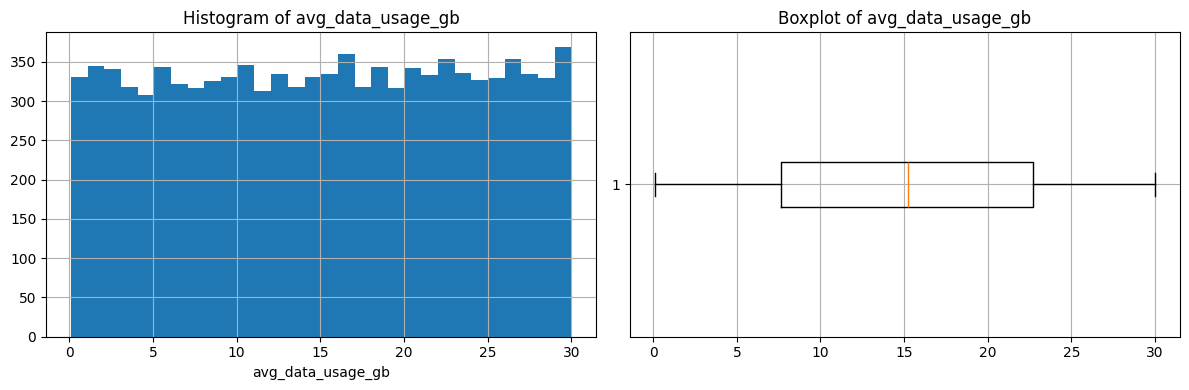

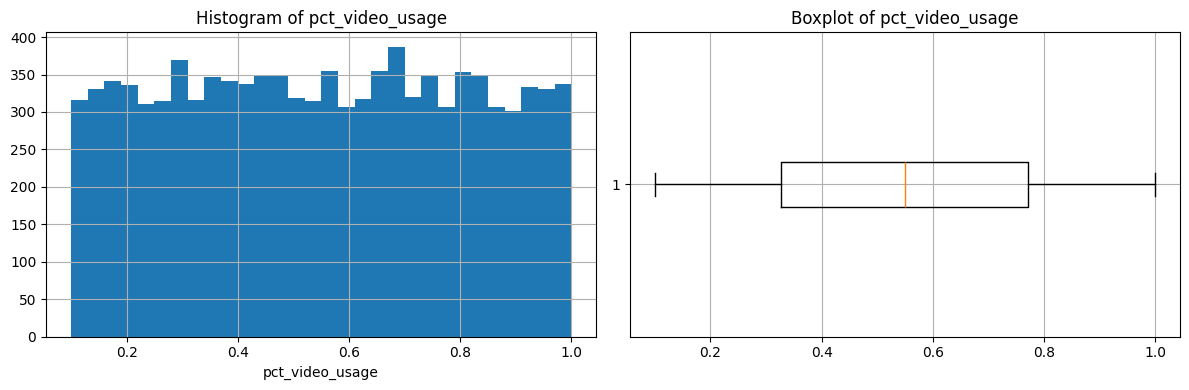

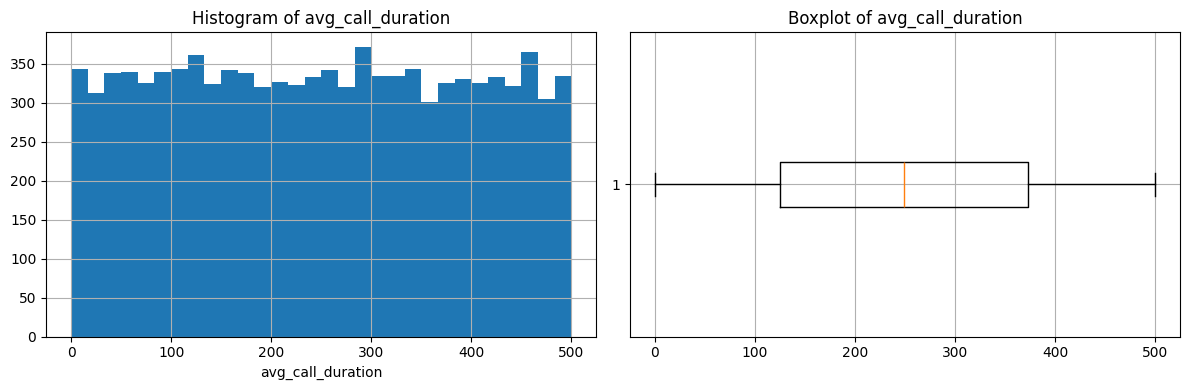

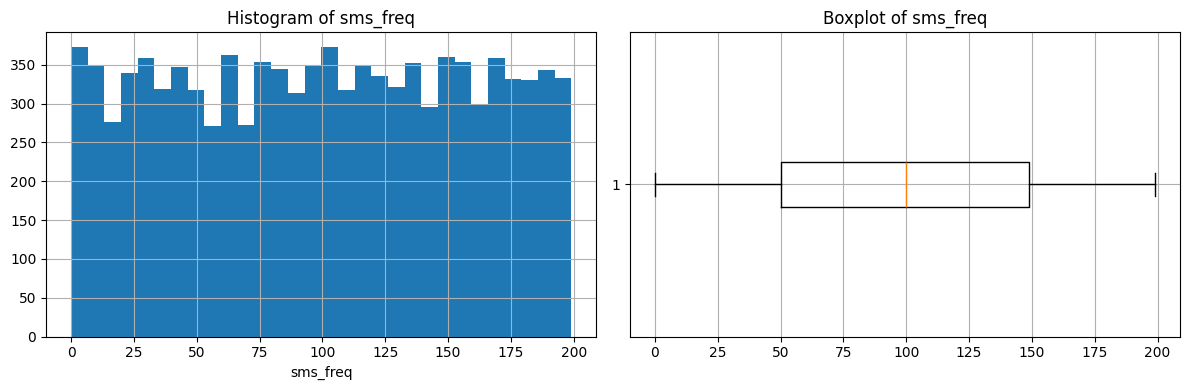

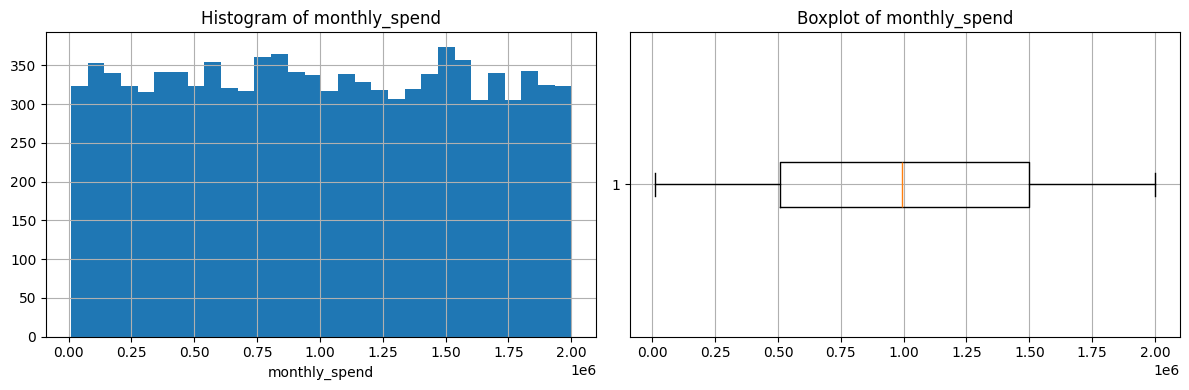

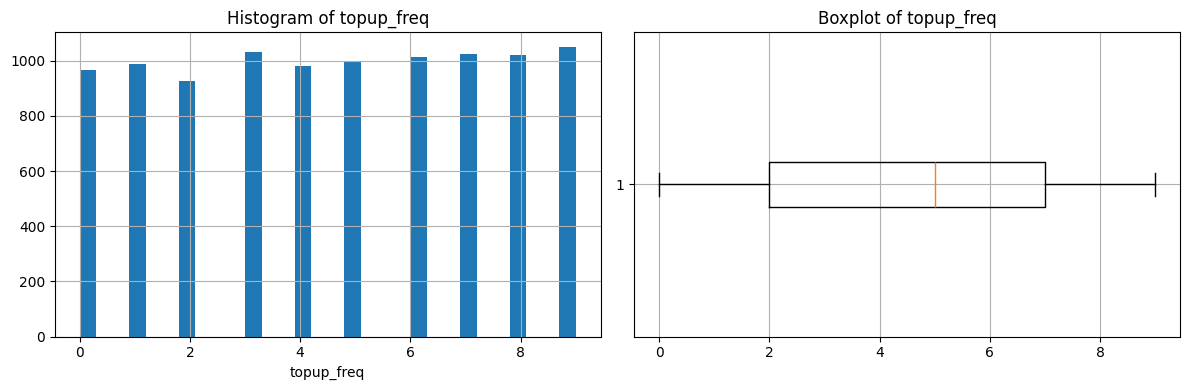

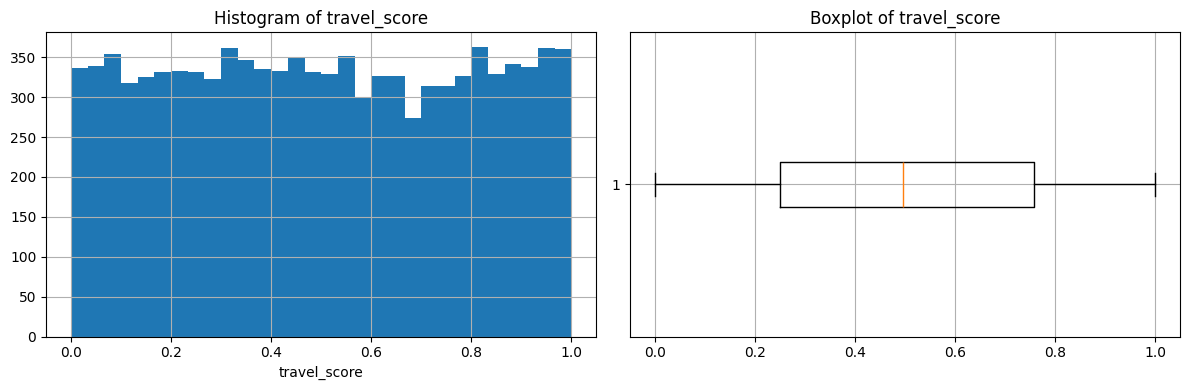

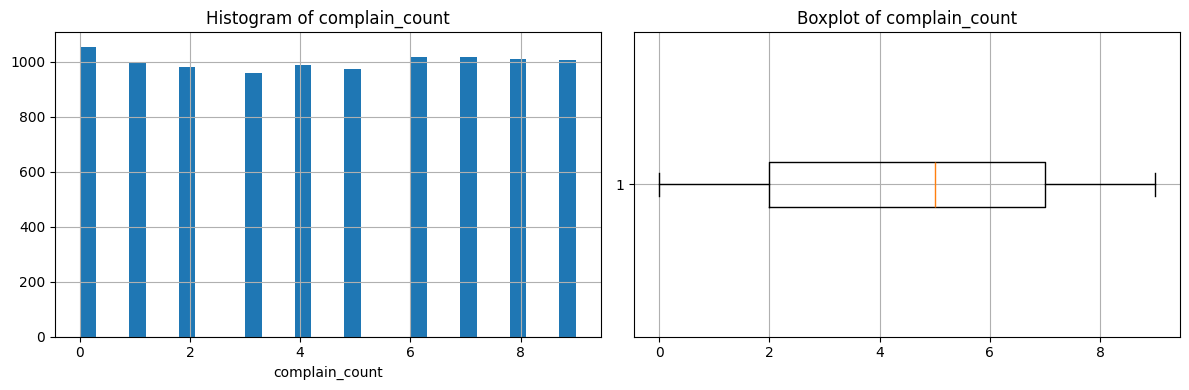

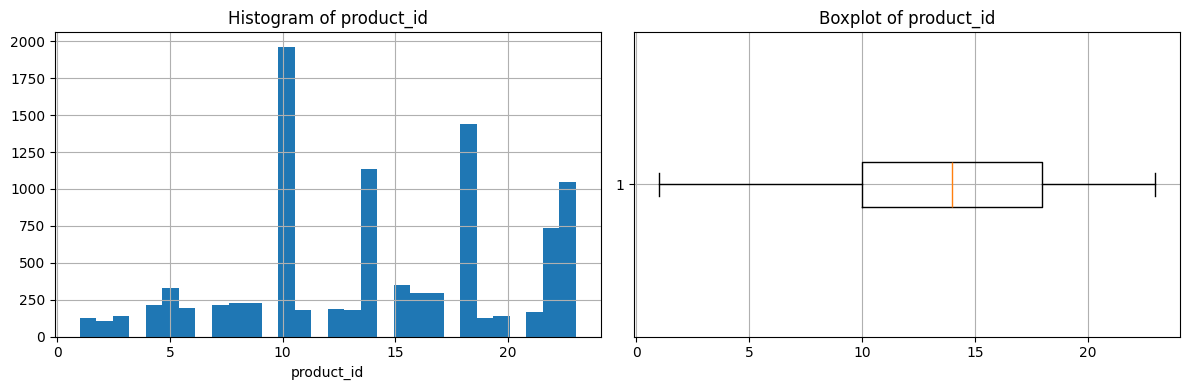

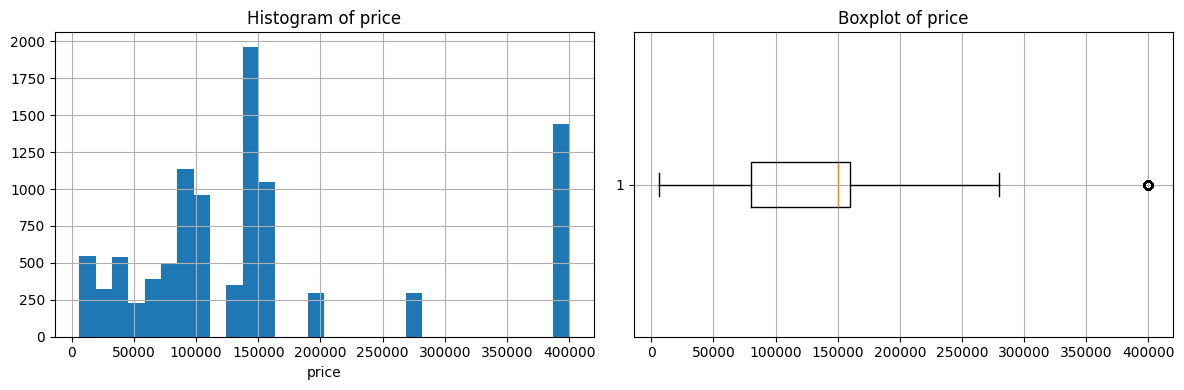

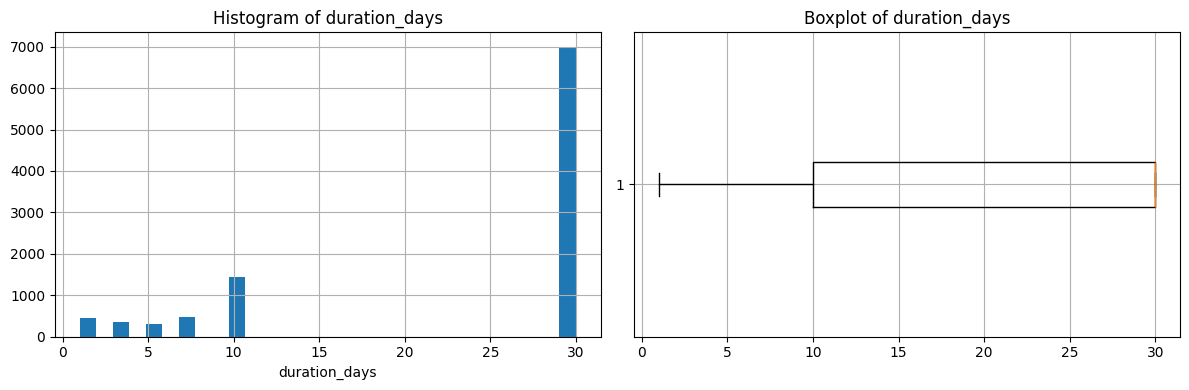

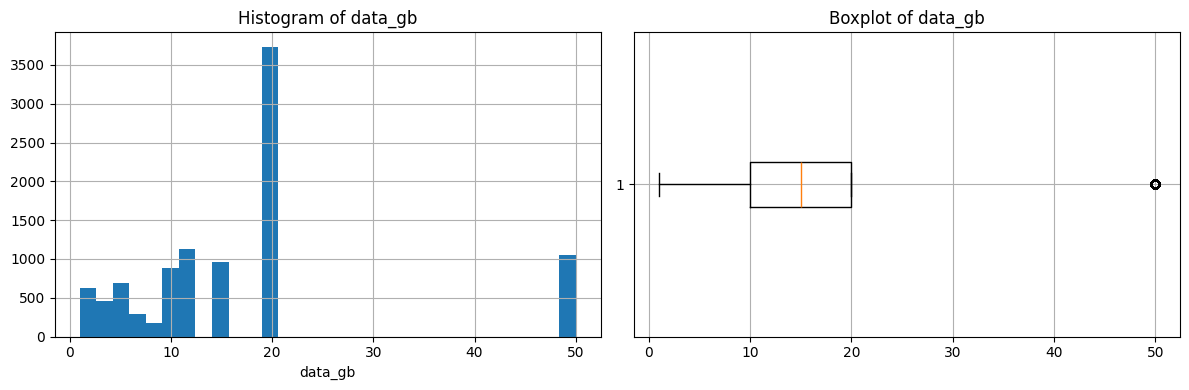

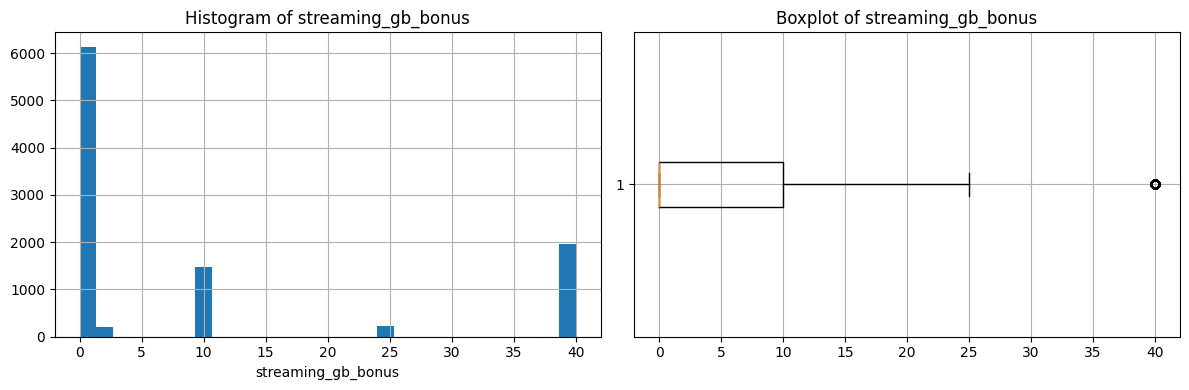

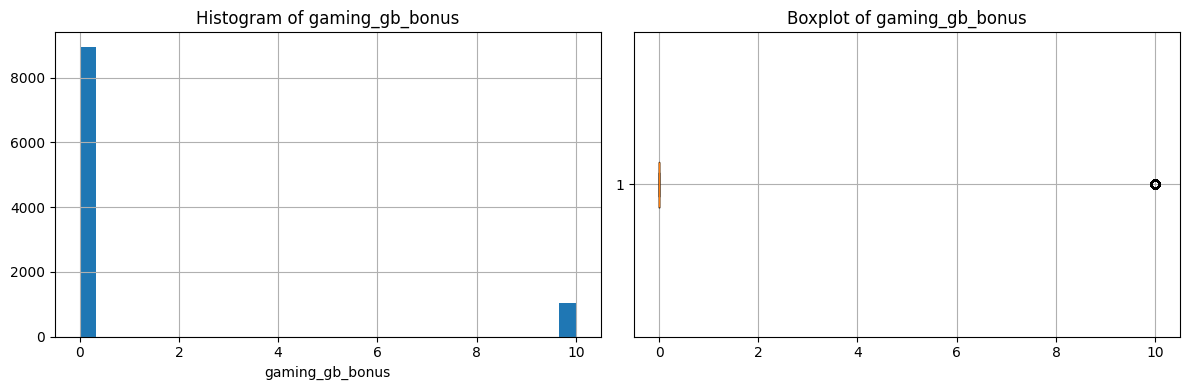

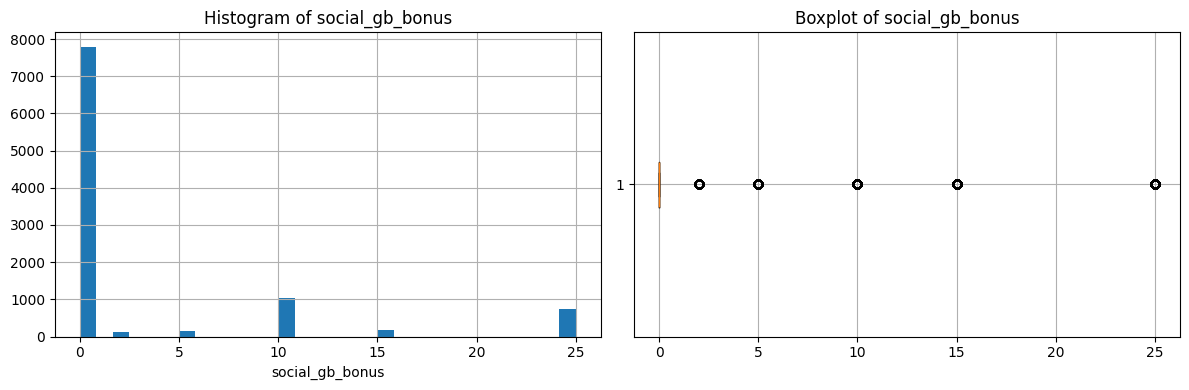

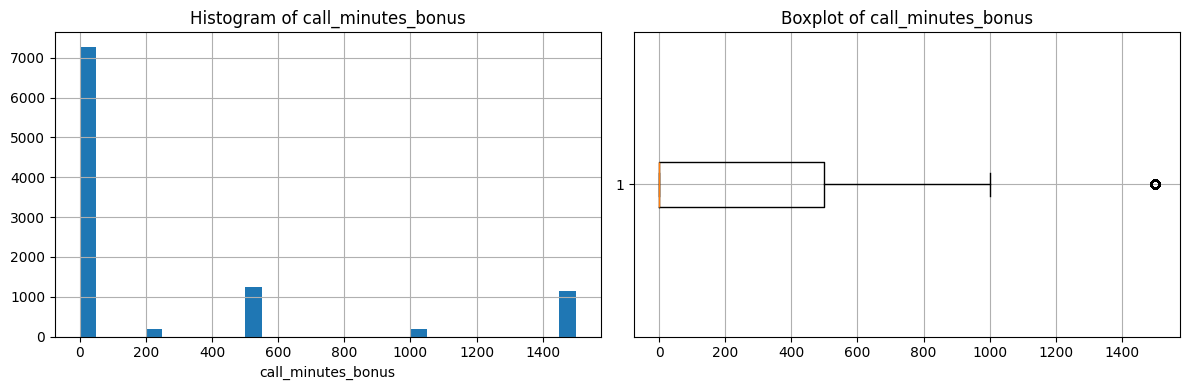

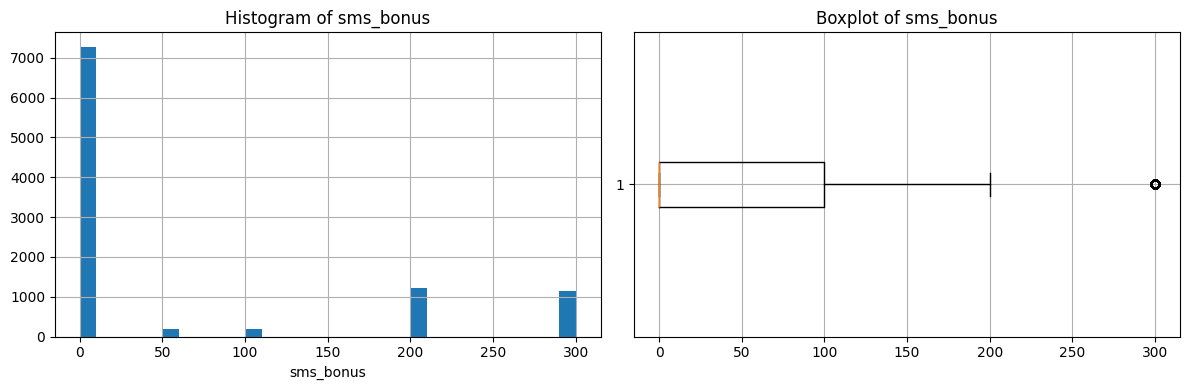

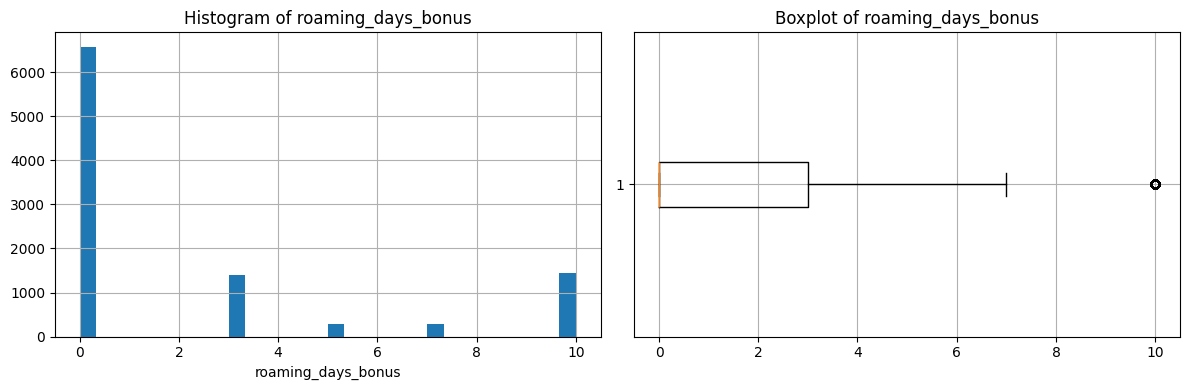

In [65]:
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    #histogram
    df[col].hist(bins=30, ax=ax[0])
    ax[0].set_title(f"Histogram of {col}")
    ax[0].set_xlabel(col)

    #boxplot
    ax[1].boxplot(df[col].dropna(), vert=False)
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

# Barplot untuk data kategorikal

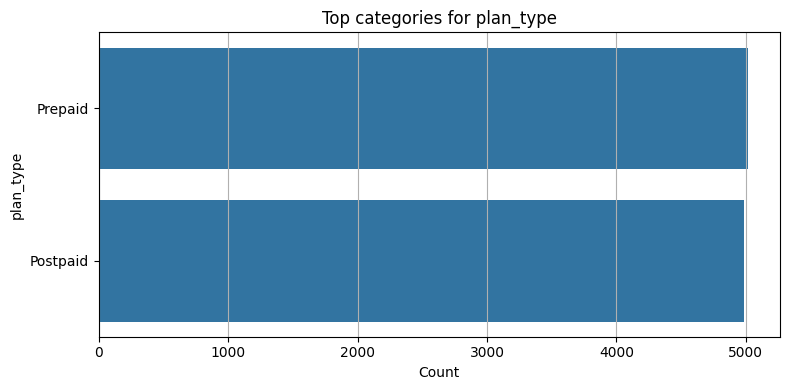

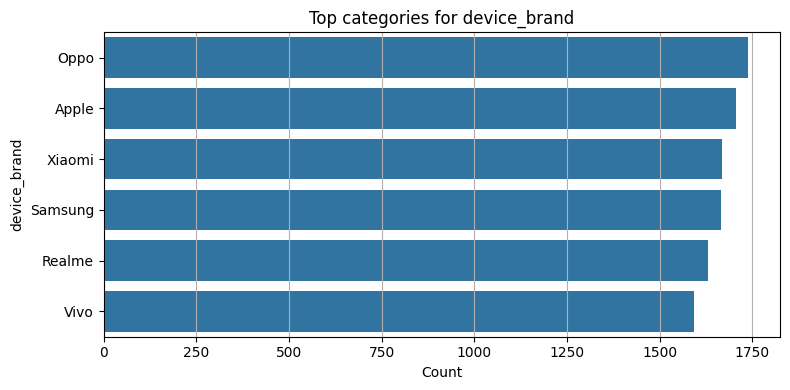

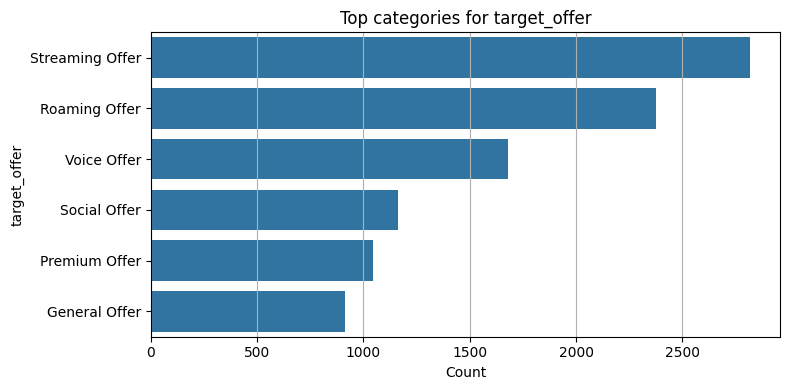

In [66]:
cat_to_plot = [c for c in cat_cols if df[c].nunique(dropna=False) <= 20][:4]

for c in cat_to_plot:
    vc = df[c].value_counts(dropna=False).head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"Top categories for {c}")
    plt.xlabel("Count")
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()

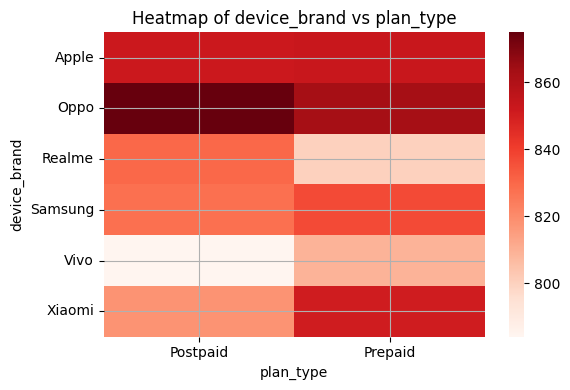

In [67]:
cat_small = [c for c in cat_cols if df[c].nunique(dropna=False) <= 15]

if len(cat_small) >= 2:
    col_x = cat_small[0]
    col_y = cat_small[1]

    ct = pd.crosstab(df[col_y], df[col_x])
    plt.figure(figsize=(6, 4))
    sns.heatmap(ct, annot=False, cmap="Reds")
    plt.title(f"Heatmap of {col_y} vs {col_x}")
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.tight_layout()
    plt.show()
else:
    print("tidak bisa bikin heatmap.")

# Correlation Matrix untuk keseluruhan dan untuk numerikal

In [68]:
df_corr = df.copy()
for c in df_corr.columns:
    if df_corr[c].dtype == "object":
        vals = df_corr[c].dropna().str.lower().unique()
        if set(vals) <= {"yes", "no"}:
            df_corr[c] = df_corr[c].str.lower().map({"no": 0, "yes": 1})


small_cats = [c for c in df_corr.columns
              if df_corr[c].dtype == "object" and df_corr[c].nunique() <= 15]

for c in small_cats:
    df_corr[c] = df_corr[c].astype("category").cat.codes


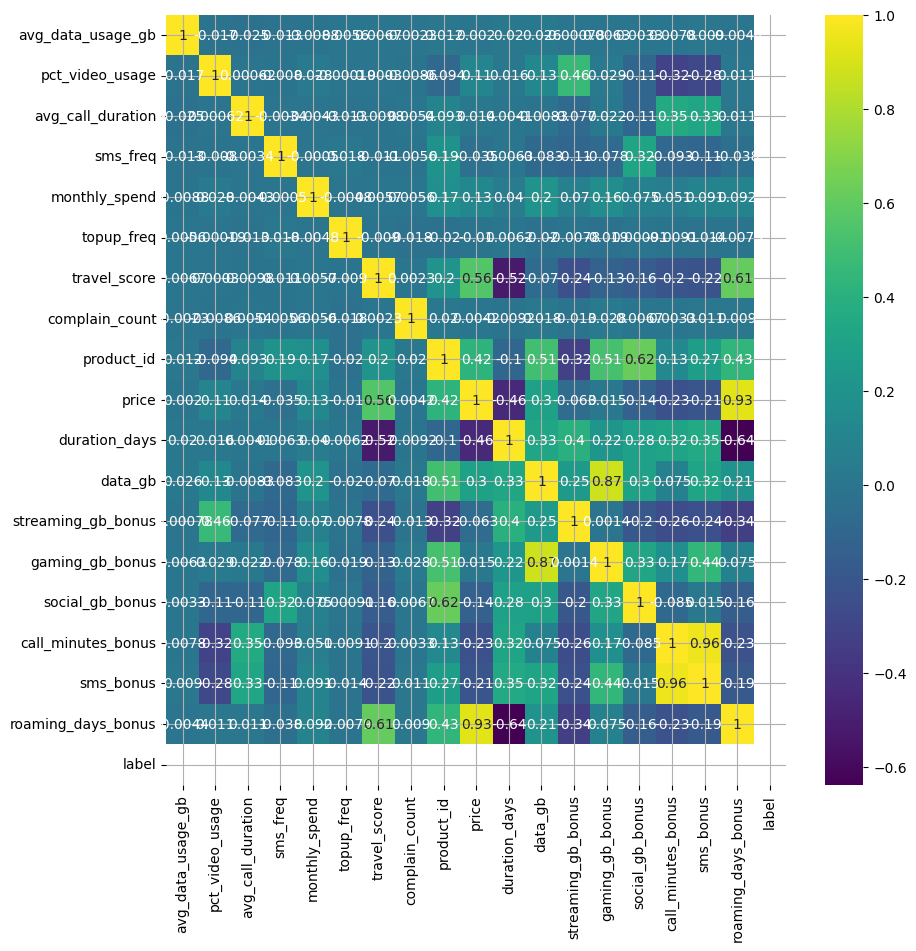

In [17]:
num_like = df_corr.select_dtypes(include=["int64", "float64"]).columns
corr = df_corr[num_like].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(
        corr,
        annot=True,
        cmap="viridis",
        xticklabels=True,
        yticklabels=True
    )
plt.show()

# Correlation Matrix untuk Numerical

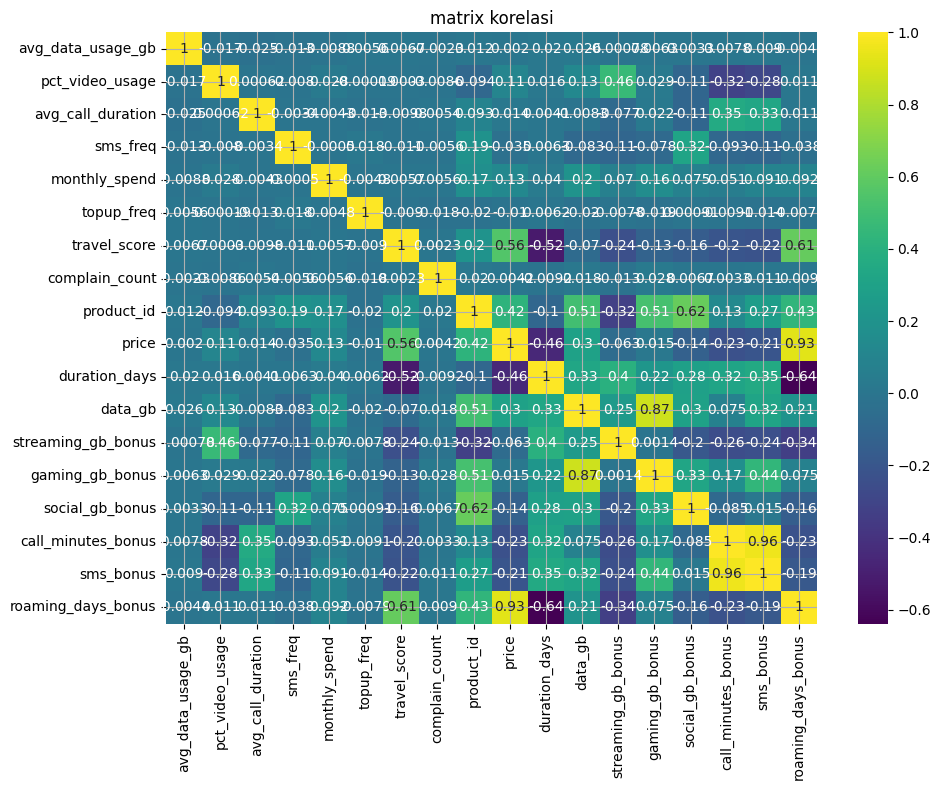

In [69]:
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        cmap="viridis",
        xticklabels=True,
        yticklabels=True
    )
    plt.title("matrix korelasi")
    plt.tight_layout()
    plt.show()
else:
    print("tidak bisa bikin matrix korelasi.")

In [70]:
profile = ProfileReport(
    df,
    title="Telco EDA Report",
    explorative=True
)
profile.to_file("telco_eda_report12.html")

print("Report generated: telco_eda_report12.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:01<00:00, 19.66it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report generated: telco_eda_report12.html


## Testing algorithm dimulai dari sini

## Test Modelling

In [71]:
SEG_COL = "plan_type"
N = 10
seg_top = (
    df.groupby(SEG_COL)["product_id"]
      .value_counts()
      .groupby(level=0)
      .head(N)
      .reset_index(name="pop_score")
)

users = df[["customer_id", SEG_COL]].drop_duplicates()

candidates = users.merge(
    seg_top,
    on=SEG_COL,
    how="left"
)[["customer_id", "product_id", "pop_score"]]

display(candidates.head())
print("candidates shape:", candidates.shape)

,customer_id,product_id,pop_score
0,C00001,10,969
1,C00001,18,726
2,C00001,14,562
3,C00001,23,527
4,C00001,22,384


candidates shape: (100000, 3)


Per plan_type, kamu ambil top-N produk paling populer (by count).

Untuk setiap user, akan di buat candidate list = produk paling populer di segmen plan_type dia.

In [72]:
ranking_df = candidates.merge(df, on=["customer_id", "product_id"], how="left")

In [73]:
# actual product per user
actual = df[["customer_id", "product_id"]].rename(columns={"product_id": "actual_product_id"})

# add actual product info to candidate rows
candidates2 = candidates.merge(actual, on="customer_id", how="left")

# rows where candidate != actual → we need to add the actual one
missing_mask = candidates2["product_id"] != candidates2["actual_product_id"]

# make rows with the actual product
forced = (
    candidates2.loc[missing_mask, ["customer_id", "actual_product_id"]]
    .drop_duplicates()
    .rename(columns={"actual_product_id": "product_id"})
)
forced["pop_score"] = 9999  # so we know it's the real one

# final candidates
candidates_final = (
    pd.concat([candidates, forced], ignore_index=True)
      .drop_duplicates(subset=["customer_id", "product_id"])
)

print("candidates_final shape:", candidates_final.shape)
candidates_final.head()


candidates_final shape: (102182, 3)


,customer_id,product_id,pop_score
0,C00001,10,969
1,C00001,18,726
2,C00001,14,562
3,C00001,23,527
4,C00001,22,384


# Labeling

In [74]:
train_pairs = candidates_final.merge(
    actual,
    on="customer_id",
    how="left"
)

train_pairs["label"] = (train_pairs["product_id"] == train_pairs["actual_product_id"]).astype(int)
train_pairs.head()
train_pairs["label"].value_counts()

,count
label,
0,92182
1,10000


label = 1 kalau candidate == actual product

label = 0 untuk candidate lain

Lalu:

user_features diambil per customer_id

product_features diambil per product_id

Di-join ke train_pairs



In [75]:
user_cols = [
    "plan_type",
    "device_brand",
    "avg_data_usage_gb",
    "pct_video_usage",
    "avg_call_duration",
    "sms_freq",
    "monthly_spend",
    "topup_freq",
    "travel_score",
    "complain_count",
]

user_features = (
    df.drop_duplicates(subset=["customer_id"])
      .set_index("customer_id")[user_cols]
)

print("user_features shape:", user_features.shape)
user_features.head()

# 4.2. Fitur product murni (atribut paket)
product_cols = [
    "product_name",
    "price",
    "duration_days",
    "data_gb",
    "streaming_gb_bonus",
    "social_gb_bonus",
    "call_minutes_bonus",
    "sms_bonus",
    "roaming_days_bonus",
    "target_offer",
]

product_features = (
    df.drop_duplicates(subset=["product_id"])
      .set_index("product_id")[product_cols]
)

print("product_features shape:", product_features.shape)
product_features.head()

user_features shape: (10000, 10)
product_features shape: (23, 10)


,product_name,price,duration_days,data_gb,streaming_gb_bonus,social_gb_bonus,call_minutes_bonus,sms_bonus,roaming_days_bonus,target_offer
product_id,,,,,,,,,,
22,SocmedMax 40GB (15+25),110000,30,15,0,25,0,0,0,Social Offer
7,StreamMax 20GB (10+10),65000,30,10,10,0,0,0,0,Streaming Offer
14,TalkMax Bulanan 12GB (1500mnt),95000,30,12,0,0,1500,300,0,Voice Offer
4,Data Pure 10GB,45000,30,10,0,0,0,0,0,General Offer
9,VideoPass 15GB (5+10),55000,30,5,10,0,0,0,0,Streaming Offer


In [76]:
train_df = (
    train_pairs
    .join(user_features, on="customer_id", rsuffix="_user")
    .join(product_features, on="product_id", rsuffix="_item")
)

train_df.head()


,customer_id,product_id,pop_score,actual_product_id,label,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,...,product_name,price,duration_days,data_gb,streaming_gb_bonus,social_gb_bonus,call_minutes_bonus,sms_bonus,roaming_days_bonus,target_offer
0,C00001,10,969,22,0,Prepaid,Vivo,17.17,0.767,196.51,...,VideoPass 60GB (20+40),150000,30,20,40,0,0,0,0,Streaming Offer
1,C00001,18,726,22,0,Prepaid,Vivo,17.17,0.767,196.51,...,Roaming Dunia 10 Hari 20GB,400000,10,20,0,0,0,0,10,Roaming Offer
2,C00001,14,562,22,0,Prepaid,Vivo,17.17,0.767,196.51,...,TalkMax Bulanan 12GB (1500mnt),95000,30,12,0,0,1500,300,0,Voice Offer
3,C00001,23,527,22,0,Prepaid,Vivo,17.17,0.767,196.51,...,Super Plan 50GB All-in-One,160000,30,50,10,10,500,200,3,Premium Offer
4,C00001,22,384,22,1,Prepaid,Vivo,17.17,0.767,196.51,...,SocmedMax 40GB (15+25),110000,30,15,0,25,0,0,0,Social Offer


label = 1 kalau candidate == actual product

label = 0 untuk candidate lain

Lalu:

user_features diambil per customer_id

product_features diambil per product_id

Di-join ke train_pairs

Ini juga cakep banget. Struktur “user × item + label” kamu tuh udah standar best practice.

In [77]:
product_features = (
    df
    .drop_duplicates(subset=["product_id"])
    .set_index("product_id")
)

product_features.head()

,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,...,price,duration_days,data_gb,streaming_gb_bonus,gaming_gb_bonus,social_gb_bonus,call_minutes_bonus,sms_bonus,roaming_days_bonus,target_offer
product_id,,,,,,,,,,,,,,,,,,,,,
22,C00001,Prepaid,Vivo,17.17,0.767,196.51,171,1289235,4,0.251,...,110000,30,15,0,0,25,0,0,0,Social Offer
7,C00002,Postpaid,Vivo,23.19,0.356,149.02,74,210699,7,0.546,...,65000,30,10,10,0,0,0,0,0,Streaming Offer
14,C00003,Prepaid,Realme,27.85,0.441,321.96,106,107964,6,0.628,...,95000,30,12,0,0,0,1500,300,0,Voice Offer
4,C00004,Prepaid,Xiaomi,7.91,0.279,50.58,47,339901,8,0.745,...,45000,30,10,0,0,0,0,0,0,General Offer
9,C00005,Prepaid,Vivo,10.11,0.974,239.05,76,1986019,2,0.029,...,55000,30,5,10,0,0,0,0,0,Streaming Offer


## Training Pair

In [78]:
train_df = train_pairs.join(user_features, on="customer_id", rsuffix="_user")
train_df = train_df.join(product_features, on="product_id", rsuffix="_item")
train_df = train_df.drop(columns=["actual_product_id"], errors="ignore")

train_df.head()

,customer_id,product_id,pop_score,label,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,...,price,duration_days,data_gb,streaming_gb_bonus,gaming_gb_bonus,social_gb_bonus,call_minutes_bonus,sms_bonus,roaming_days_bonus,target_offer
0,C00001,10,969,0,Prepaid,Vivo,17.17,0.767,196.51,171,...,150000,30,20,40,0,0,0,0,0,Streaming Offer
1,C00001,18,726,0,Prepaid,Vivo,17.17,0.767,196.51,171,...,400000,10,20,0,0,0,0,0,10,Roaming Offer
2,C00001,14,562,0,Prepaid,Vivo,17.17,0.767,196.51,171,...,95000,30,12,0,0,0,1500,300,0,Voice Offer
3,C00001,23,527,0,Prepaid,Vivo,17.17,0.767,196.51,171,...,160000,30,50,10,10,10,500,200,3,Premium Offer
4,C00001,22,384,1,Prepaid,Vivo,17.17,0.767,196.51,171,...,110000,30,15,0,0,25,0,0,0,Social Offer


## Persiapan Modelling

In [103]:

y = train_df["label"]

drop_cols = [
    "label",
    "customer_id",
    "product_name",
    "pop_score",
]

print(f"Membuang kolom: {drop_cols}")
X = train_df.drop(columns=drop_cols, errors="ignore")

print("Menjalankan pd.get_dummies() untuk fitur kategori...")
X_enc = pd.get_dummies(X, drop_first=True)

print(f"Data siap dengan {len(X_enc.columns)} fitur.")
X_enc.head()


Membuang kolom: ['label', 'customer_id', 'product_name', 'pop_score']
Menjalankan pd.get_dummies() untuk fitur kategori...
Data siap dengan 64 fitur.


,product_id,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complain_count,avg_data_usage_gb_item,...,plan_type_item_Prepaid,device_brand_item_Oppo,device_brand_item_Realme,device_brand_item_Vivo,device_brand_item_Xiaomi,target_offer_Premium Offer,target_offer_Roaming Offer,target_offer_Social Offer,target_offer_Streaming Offer,target_offer_Voice Offer
0,10,17.17,0.767,196.51,171,1289235,4,0.251,9,3.29,...,True,False,False,True,False,False,False,False,True,False
1,18,17.17,0.767,196.51,171,1289235,4,0.251,9,12.32,...,False,False,False,False,False,False,True,False,False,False
2,14,17.17,0.767,196.51,171,1289235,4,0.251,9,27.85,...,True,False,True,False,False,False,False,False,False,True
3,23,17.17,0.767,196.51,171,1289235,4,0.251,9,27.82,...,True,False,False,True,False,True,False,False,False,False
4,22,17.17,0.767,196.51,171,1289235,4,0.251,9,17.17,...,True,False,False,True,False,False,False,True,False,False


# **Split data training dan valuasi**

In [104]:
all_users = train_df["customer_id"].unique()

users_train, users_val = train_test_split(
    all_users, test_size=0.2, random_state=42
)

train_mask = train_df["customer_id"].isin(users_train)
val_mask   = train_df["customer_id"].isin(users_val)

X_train = X_enc.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X_enc.loc[val_mask]
y_val = y.loc[val_mask]

print("Train shape:", X_train.shape, "Pos ratio:", y_train.mean().round(4))
print("Val   shape:", X_val.shape,   "Pos ratio:", y_val.mean().round(4))


Train shape: (81740, 64) Pos ratio: 0.0979
Val   shape: (20442, 64) Pos ratio: 0.0978


In [105]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", pos_weight)

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=pos_weight,
    random_state=42,
)

print("Mulai melatih model...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],  # ini masih oke
    verbose=False,              # atau True kalau mau lihat log
)
print("Training selesai.")

# Simpan model + blueprint kolom
joblib.dump(model, "xgb_recsys_model.pkl")
joblib.dump(list(X_enc.columns), "xgb_model_columns.pkl")

print("Model & kolom fitur disimpan.")

scale_pos_weight: 9.2175
Mulai melatih model...
Training selesai.
Model & kolom fitur disimpan.


In [106]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred  = (y_val_proba >= 0.5).astype(int)

print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))
print("\nClassification report (threshold 0.5):")
print(classification_report(y_val, y_val_pred))


Validation ROC AUC: 0.9569210226656546

Classification report (threshold 0.5):
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     18442
           1       0.68      0.89      0.77      2000

    accuracy                           0.95     20442
   macro avg       0.83      0.92      0.87     20442
weighted avg       0.96      0.95      0.95     20442



In [107]:
val_df = train_df.loc[val_mask].copy()
val_df["y_proba"] = y_val_proba

def hit_rate_at_k(df_val, k=5):
    # sort per user berdasarkan proba desc
    df_sorted = df_val.sort_values(
        ["customer_id", "y_proba"],
        ascending=[True, False]
    )
    # ambil top-k candidate per user
    topk = df_sorted.groupby("customer_id").head(k)
    # untuk tiap user: apakah ada label=1 di top-k?
    hit_per_user = topk.groupby("customer_id")["label"].max()
    # rata-rata hit rate
    return hit_per_user.mean()

for k in [1, 3, 5, 10]:
    hr = hit_rate_at_k(val_df, k=k)
    print(f"Hit Rate@{k}: {hr:.4f}")


Hit Rate@1: 0.8720
Hit Rate@3: 0.9440
Hit Rate@5: 0.9745
Hit Rate@10: 1.0000


In [93]:
val_idx = X_val.index

val_preds = pd.DataFrame({
    "customer_id": train_df.loc[val_idx, "customer_id"].values,
    "product_id":  train_df.loc[val_idx, "product_id"].values,
    "label":       y_val.values,
    "score":       y_val_proba,
})

top_val = (
    val_preds
    .sort_values(["customer_id", "score"], ascending=[True, False])
    .groupby("customer_id")
    .head(5)
)

top_val.head(20)


,customer_id,product_id,label,score
4,C00001,22,1,0.827466
0,C00001,10,0,0.666400
9,C00001,7,0,0.114173
3,C00001,23,0,0.062660
6,C00001,15,0,0.047708
20000,C00004,4,1,0.999543
15,C00004,5,0,0.375634
19,C00004,7,0,0.246862
13,C00004,23,0,0.223080
10,C00004,10,0,0.110247


In [83]:
cols_we_want = ["product_id", "product_name", "target_offer", "duration", "spending_tier"]


cols_in_df = [c for c in cols_we_want if c in df.columns]

product_lookup = (
    df[cols_in_df]
      .drop_duplicates(subset=["product_id"])
      .set_index("product_id")
)

product_lookup.head()


,product_name,target_offer
product_id,,
22,SocmedMax 40GB (15+25),Social Offer
7,StreamMax 20GB (10+10),Streaming Offer
14,TalkMax Bulanan 12GB (1500mnt),Voice Offer
4,Data Pure 10GB,General Offer
9,VideoPass 15GB (5+10),Streaming Offer
